* this notebook uses parallel job division to allow the HPC to run the script faster on multiple CPU's

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from Tracer import WindField, Fluctuator, Trajectory, PGA
from joblib import Parallel, delayed
import joblib
from matplotlib.patches import Ellipse

In [6]:
# check cores
import multiprocessing
print(multiprocessing.cpu_count())

16


In [5]:
file = r'C:\Users\jacob\OneDrive - Danmarks Tekniske Universitet\UNI\6 semester\Bachelor\Bachelor_legeplads\demos\nc files\flowdata_z0_0.03_mb_cartesian.nc'
(wind := WindField(profile='rans', ds=file, U_ref=6.0))

WindField(profile=rans) 
Size: 24MB
Dimensions:  (x: 65, y: 65, z: 100)
Coordinates:
  * x        (x) float64 520B -128.0 -124.0 -120.0 -116.0 ... 120.0 124.0 128.0
  * y        (y) float64 520B -128.0 -124.0 -120.0 -116.0 ... 120.0 124.0 128.0
  * z        (z) float64 800B 0.1 0.1072 0.115 0.1233 ... 86.97 93.26 100.0
Data variables:
    U        (x, y, z) float64 3MB 1.403 1.462 1.525 1.593 ... 8.233 8.304 8.375
    V        (x, y, z) float64 3MB -4.175e-06 -4.349e-06 ... 8.259e-06 8.379e-06
    W        (x, y, z) float64 3MB -3.501e-09 -3.878e-09 ... -9.874e-05
    P        (x, y, z) float64 3MB ...
    muT      (x, y, z) float64 3MB ...
    tke      (x, y, z) float64 3MB 0.9937 0.9953 0.9969 ... 0.977 0.9776 0.9782
    epsilon  (x, y, z) float64 3MB 1.634 1.554 1.468 ... 0.001853 0.00173
Attributes:
    PyWakeEllipSys_version:  6.1
    xWFc:                    0.0
    yWFc:                    0.0
    grid_wd:                 270.0
    resolution:              4.0
    scaling:      

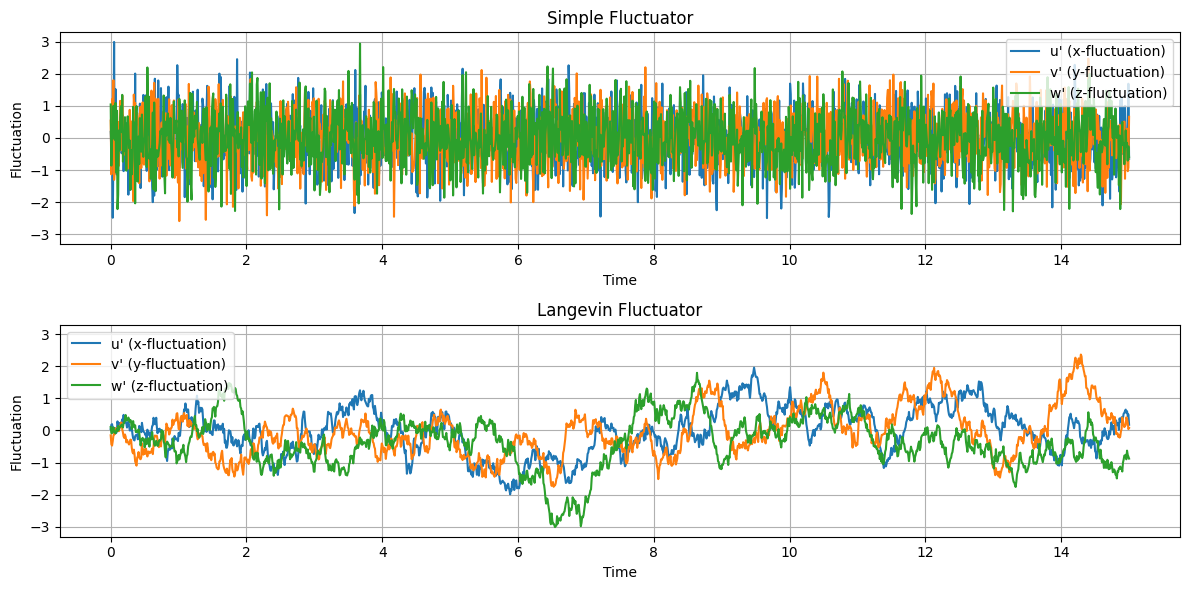

In [4]:
# visualize the temporal fluctuation profiles
simple_fluc = Fluctuator(method='simple')
langevin_fluc = Fluctuator(method='langevin', seed=42)

n = int(15/0.01)

fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharey=True)
simple_fluc.plot(ax=axs[0], range=(0,15), num_points=n)
axs[0].set_title('Simple Fluctuator')
langevin_fluc.plot(ax=axs[1], range=(0,15), num_points=n)

axs[1].set_title('Langevin Fluctuator')
plt.tight_layout()
plt.show()

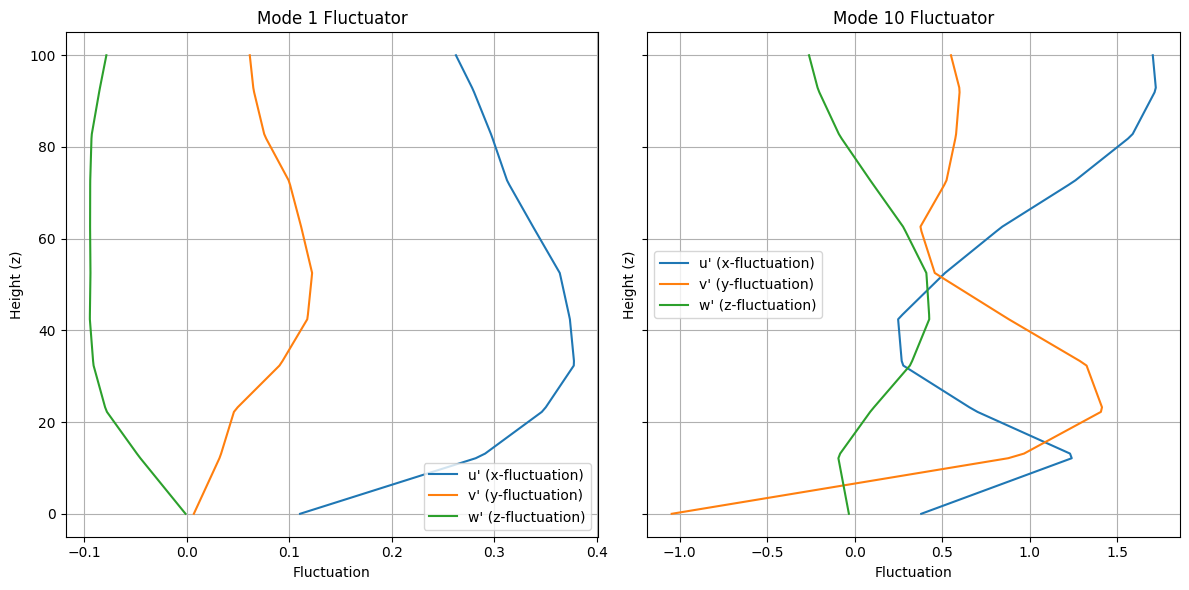

In [5]:
# visualize the spatial fluctuation profiles
mode1_fluc = Fluctuator(method='pod', n_modes=1)
mode10_fluc = Fluctuator(method='pod', n_modes=10) 

fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
mode1_fluc.plot(ax=axs[0])
axs[0].set_title('Mode 1 Fluctuator')
mode10_fluc.plot(ax=axs[1])
axs[1].set_title('Mode 10 Fluctuator')
plt.tight_layout()
plt.show()

In [6]:
# Define a helper function for a single run to be used in parallel processing
def simulate_single_shot(method, wind, dt, n_modes=10, **kwargs):
    # Re-initialize or pass objects safely inside the worker
    fluc = Fluctuator(method=method, **kwargs, n_modes=n_modes)
    traj = PGA('Driver', fluc=fluc, wind=wind)
    
    traj.solve('euler', dt)
    return traj.p[-1][:2]

# Standard deviation as function of dt

In [8]:
methods = ['simple', 'langevin', 'pod']
time_steps = [0.1, 0.03, 0.01, 0.003, 0.001, 0.0003, 0.0001]
try:
    landing_points_dt = joblib.load('landing_points_all_methods_9.joblib')
    print("Loaded existing results from file")
except FileNotFoundError:

    landing_points_dt = {method: {dt: [] for dt in time_steps} for method in methods}

    # 3. Run in parallel across your allocated HPC cores
    # n_jobs=-1 will automatically use ALL cores you requested via bsub

    for method in methods:
        for dt in time_steps:
                results = Parallel(n_jobs=-1)(
                    delayed(simulate_single_shot)(method=method, wind=wind, n_modes=9, dt=dt) for _ in range(200)
                )
                landing_points_dt[method][dt] = results

    joblib.dump(landing_points_dt, 'landing_points_all_methods_9.joblib', compress=3)

p_ref = {dt: [] for dt in time_steps}
traj = PGA('Driver', wind=wind)
for dt in time_steps:
    traj.solve('euler', dt)
    p_ref[dt] = traj.p[-1][:2]

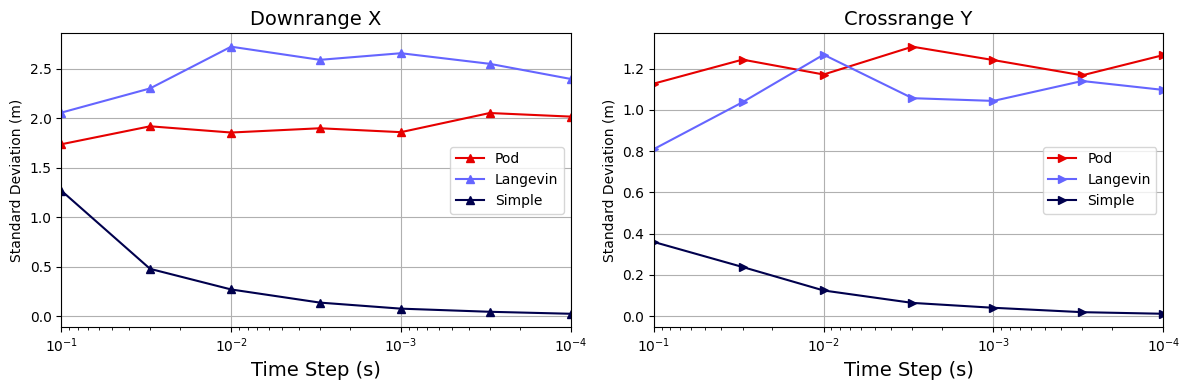

In [23]:
colors = plt.cm.seismic([0.0, 0.35, 0.8])

std_dev = {method: [] for method in methods}
for method in methods:
    for dt in time_steps:
        diffs = np.array(landing_points_dt[method][dt]) - p_ref[dt]
        std_dev[method].append(np.std(diffs, axis=0))

fig, ax = plt.subplots(1,2, figsize=(12, 4), sharex=True)
for i, method in enumerate(methods[::-1]):
    ax[0].plot(time_steps, [s[0] for s in std_dev[method]], label=f'{method.title()}', marker='^', color=colors[::-1][i])
    ax[1].plot(time_steps, [s[1] for s in std_dev[method]], label=f'{method.title()}', marker='>', color=colors[::-1][i])
    # set x-axis to log scale that goes from 0.1 to 0.0001
    ax[0].set_xscale('log')
    ax[1].set_xscale('log')
    ax[0].set_xlim(0.1, 0.0001)
    ax[1].set_xlim(0.1, 0.0001)
    ax[0].set_ylabel('Standard Deviation (m)')
    ax[1].set_ylabel('Standard Deviation (m)')
    ax[0].grid()
    ax[1].grid()
ax[0].set_title('Downrange X', fontsize=14)
ax[1].set_title('Crossrange Y', fontsize=14)
ax[0].set_xlabel('Time Step (s)', fontsize=14)
ax[1].set_xlabel('Time Step (s)', fontsize=14)
ax[0].legend()
ax[1].legend()
#plt.suptitle('Standard Deviation of Landing Point vs Time Step for Different Fluctuation Methods')
plt.tight_layout()
plt.show()

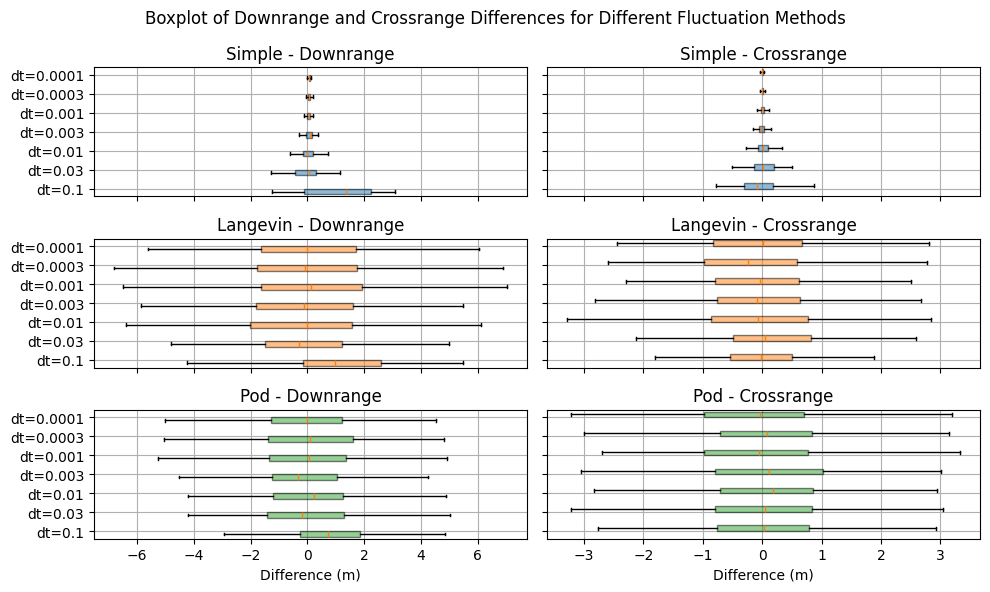

In [12]:
# boxplot of downrange and crossrange for each method at each time step
fig, ax = plt.subplots(3,2, figsize=(10, 6), sharey=True, sharex='col')
for i, method in enumerate(methods):
    data_downrange = [p_ref[dt][0] - np.array(landing_points_dt[method][dt])[:, 0] for dt in time_steps]
    data_crossrange = [p_ref[dt][1] - np.array(landing_points_dt[method][dt])[:, 1] for dt in time_steps]
    
    bplot_down = ax[i, 0].boxplot(data_downrange, positions=np.arange(len(time_steps))*2.0-0.3, widths=0.6, patch_artist=True, boxprops=dict(facecolor='C'+str(i), alpha=0.5), orientation='horizontal', showfliers=False)
    bplot_cross = ax[i, 1].boxplot(data_crossrange, positions=np.arange(len(time_steps))*2.0+0.3, widths=0.6, patch_artist=True, boxprops=dict(facecolor='C'+str(i), alpha=0.5), orientation='horizontal', showfliers=False)

    ax[i, 0].set_yticks(np.arange(len(time_steps))*2.0, [f'dt={dt}' for dt in time_steps])
    ax[i, 0].set_title(f'{method.title()} - Downrange')
    ax[i, 1].set_title(f'{method.title()} - Crossrange')
    ax[i, 0].grid()
    ax[i, 1].grid()
plt.suptitle(f'Boxplot of Downrange and Crossrange Differences for Different Fluctuation Methods')
ax[2, 0].set_xlabel('Difference (m)')
ax[2, 1].set_xlabel('Difference (m)')
plt.tight_layout()
plt.show()

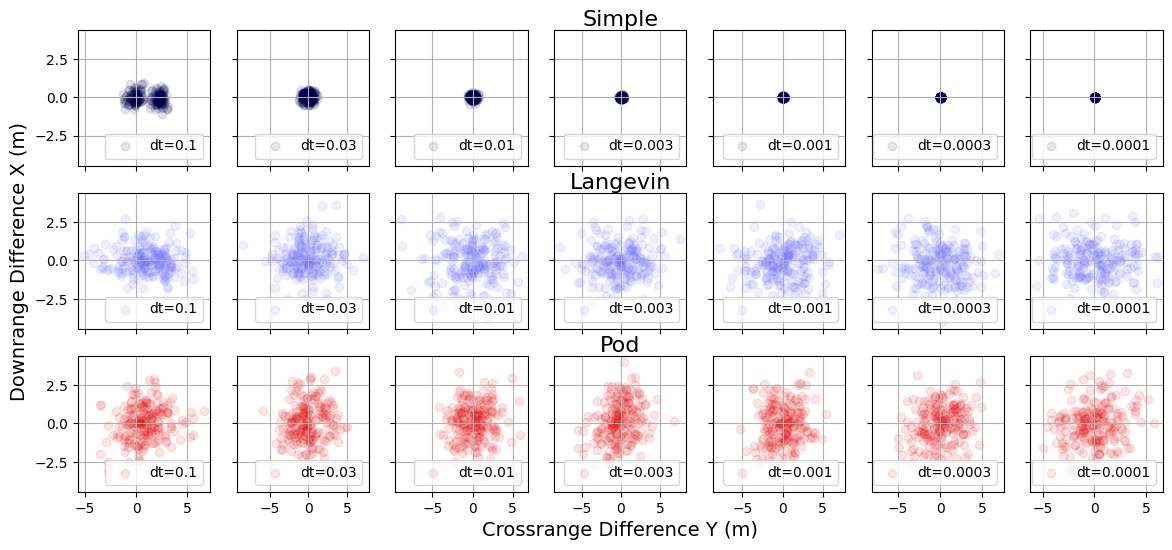

In [27]:
# scatter plot downrange and crossrange for each method at each time step


fig, ax = plt.subplots(3,7, figsize=(14, 6), sharex='col', sharey=True)
for i, method in enumerate(methods):
    for j, dt in enumerate(time_steps):
        centered_data = p_ref[dt] - np.array(landing_points_dt[method][dt])
        ax[i, j].scatter(centered_data[:, 0], centered_data[:, 1], label=f'dt={dt}', alpha=0.1, color=colors[i])
        ax[i, j].legend(loc='lower right')
        ax[i, j].grid()
    ax[i, 3].set_title(method.title(), fontsize=16, pad=-10)

#plt.suptitle(f'Scatter Plot of Downrange and Crossrange Differences for Different Fluctuation Methods')
ax[1, 0].set_ylabel('Downrange Difference X (m)', fontsize=14)
ax[2, 3].set_xlabel('Crossrange Difference Y (m)', fontsize=14)
#plt.tight_layout()
plt.show()

# Analysis of POD mode fluctuation of n_modes in 3x3

In [28]:
# 2. Set up your parameters
modes = range(1, 15)

landing_points_modes = {mode: [] for mode in modes}

# 3. Run in parallel across your allocated HPC cores
# n_jobs=-1 will automatically use ALL cores you requested via bsub
for mode in modes:
    results = Parallel(n_jobs=-1)(
        delayed(simulate_single_shot)(method='POD', n_modes=mode, wind=wind, seed=i, dt=0.01) for i in range(200)
    )
    landing_points_modes[mode] = results

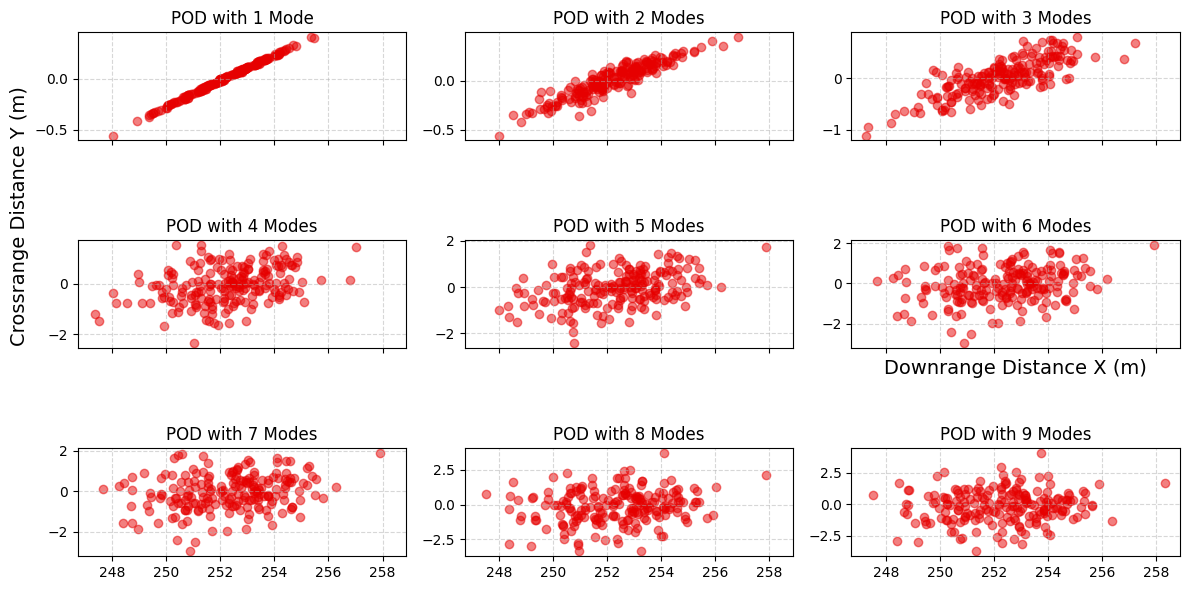

In [47]:

fig, axs = plt.subplots(3,3,figsize=(12, 6), sharex=True)
for mode in modes[:9]:
    points = np.array(landing_points_modes[mode])
    
    row, col = divmod(mode-1, 3)
    axs[row, col].scatter(points[:, 0], points[:, 1], alpha=0.5, color=colors[2])
    axs[row, col].set_title(f'POD with {mode} Mode{"s" if mode > 1 else ""}')
    axs[row, col].grid(True, which='both', linestyle='--', alpha=0.5)
    #axs[row, col].axis('equal')


# create subplot to add extra title and axis labels
axs[0, 0].set_ylabel('Crossrange Distance Y (m)', ha='right', fontsize=14)
axs[1, 2].set_xlabel('Downrange Distance X (m)', fontsize=14)

#plt.suptitle('Landing Points of Trajectories with Different Number of POD Modes', fontsize=16)  
plt.tight_layout()
plt.show()

# Compare landing positions for different fluctuators

In [32]:
methods = ['Simple', 'Langevin', 'POD']

landing_points = {method: [] for method in methods}

# 3. Run in parallel across your allocated HPC cores
# n_jobs=-1 will automatically use ALL cores you requested via bsub
for method in methods:
    results = Parallel(n_jobs=-1)(
        delayed(simulate_single_shot)(method=method, wind=wind, n_modes=9, dt=0.01) for _ in range(200)
    )
    landing_points[method] = results

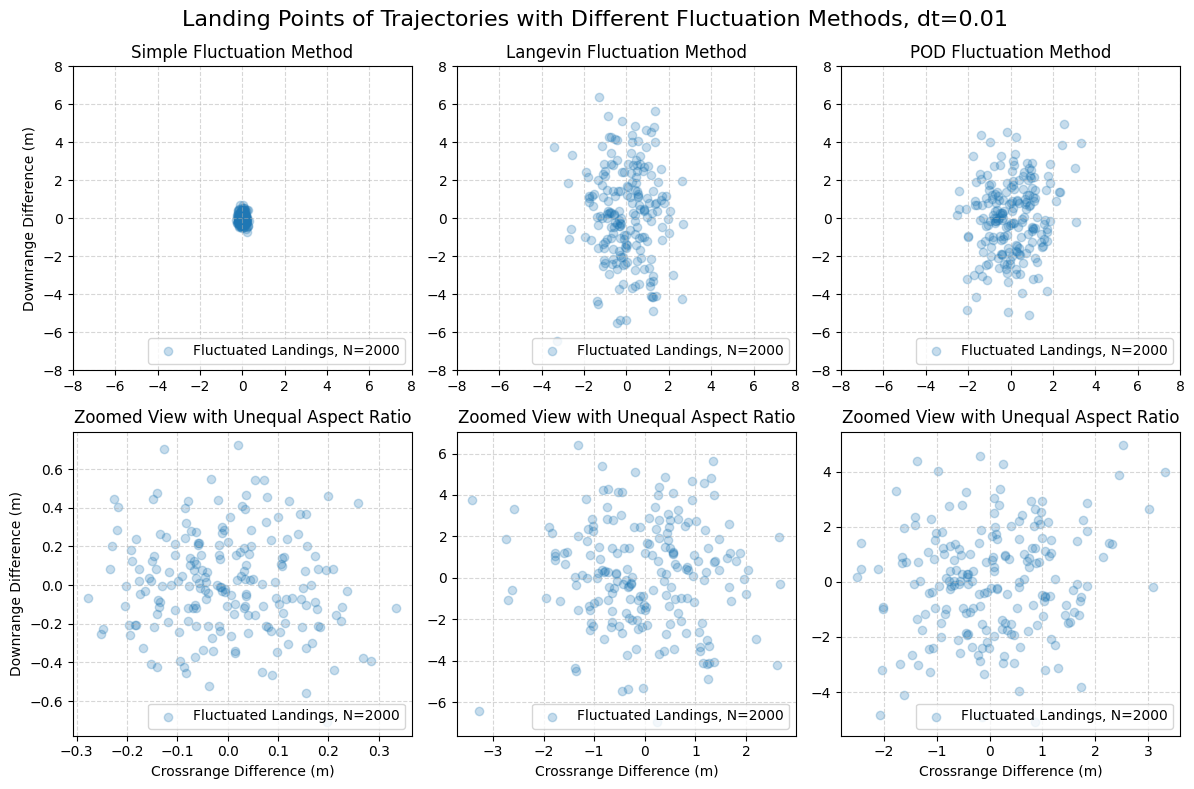

In [35]:
traj = PGA('Driver', wind=wind)
traj.solve('euler', dt=0.01)

reference_point = traj.p[-1][:2]

fig, axs = plt.subplots(2,3,figsize=(12, 8))

# for i, method in enumerate(['Simple', 'POD']):
for i, method in enumerate(methods):
    points = np.array(landing_points[method])
    axs[0, i].scatter(reference_point[1]-points[:, 1], reference_point[0]-points[:, 0], alpha=0.25, label='Fluctuated Landings, N=2000')
    axs[1, i].scatter(reference_point[1]-points[:, 1], reference_point[0]-points[:, 0], alpha=0.25, label='Fluctuated Landings, N=2000')
    #axs[i].scatter(reference_point[1], reference_point[0], color='red', label='Reference Landing', edgecolor='black', s=60)
    axs[0, i].set_title(f'{method[0].upper() + method[1:]} Fluctuation Method')
    axs[0, i].set_xlim(-8,8)
    axs[0, i].set_ylim(-8,8)
    axs[0, i].set_title(f'{method[0].upper() + method[1:]} Fluctuation Method')
    axs[1, i].set_title(f'Zoomed View with Unequal Aspect Ratio')
    axs[1, i].set_xlabel('Crossrange Difference (m)')
    axs[0, i].legend(loc='lower right')
    axs[1, i].legend(loc='lower right')
    axs[0, i].grid(True, which='both', linestyle='--', alpha=0.5)
    axs[1, i].grid(True, which='both', linestyle='--', alpha=0.5)
axs[0, 0].set_ylabel('Downrange Difference (m)')
axs[1, 0].set_ylabel('Downrange Difference (m)')
plt.suptitle('Landing Points of Trajectories with Different Fluctuation Methods, dt=0.01', fontsize=16)
plt.tight_layout()
plt.show()

In [15]:
anka_mean = {'ball_speed': 71.5, 'launch_angle': 11, 'spin_rate': 2100, 'spin_axis': -0.5, 'orientation': 0}
anka_std = {'ball_speed': 1, 'launch_angle': 0.9, 'spin_rate': 700, 'spin_axis': 1, 'orientation': 1.8}
anka_std = {'ball_speed': 1, 'launch_angle': 0.9, 'spin_rate': 200, 'spin_axis': 1, 'orientation': 1.8}

rng = np.random.default_rng()
# Define a helper function for a single run to be used in parallel processing
def simulate_random_shot():
    # Re-initialize or pass objects safely inside the worker
    ball_speed = rng.normal(loc=anka_mean['ball_speed'], scale=anka_std['ball_speed'])
    launch_angle = rng.normal(loc=anka_mean['launch_angle'], scale=anka_std['launch_angle'])
    spin_rate = rng.normal(loc=anka_mean['spin_rate'], scale=anka_std['spin_rate'])
    spin_axis = rng.normal(loc=anka_mean['spin_axis'], scale=anka_std['spin_axis'])
    orientation = rng.normal(loc=anka_mean['orientation'], scale=anka_std['orientation'])
    # print(f"Simulating shot with ball_speed={ball_speed:.2f}, launch_angle={launch_angle:.2f}, spin_rate={spin_rate:.2f}, spin_axis={spin_axis:.2f}")
    traj = Trajectory(
        ball_speed=ball_speed,
        launch_angle=launch_angle,
        spin_rate=spin_rate,
        spin_axis=spin_axis,
        orientation=orientation,
        wind=wind #WindField('uniform', U_ref=0)
        )

    traj.solve()

    return traj.p[-1][:2]

In [16]:
results = [simulate_random_shot() for _ in range(1000)]

ref_traj = Trajectory(
    ball_speed=anka_mean['ball_speed'],
    launch_angle=anka_mean['launch_angle'],
    spin_rate=anka_mean['spin_rate'],
    spin_axis=anka_mean['spin_axis'],
    wind=wind # WindField('uniform', U_ref=0)
)
ref_traj.solve()
ref_point = ref_traj.p[-1][:2]

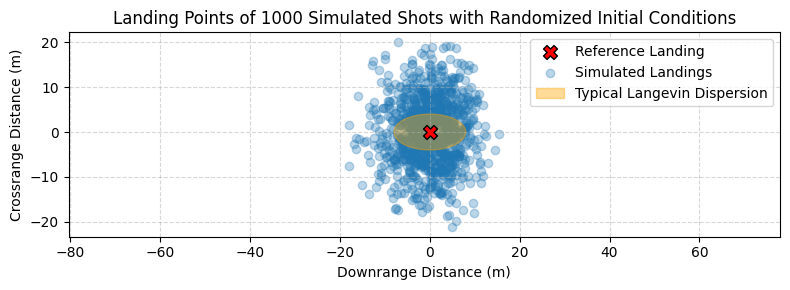

In [17]:
from matplotlib.patches import Ellipse
ax, fig = plt.subplots(figsize=(8, 3))
plt.scatter(0,0, marker='X', color='red', label='Reference Landing', edgecolor='black', s=100, zorder=5)
plt.scatter(np.array(results)[:, 0] - ref_point[0], np.array(results)[:, 1] - ref_point[1], alpha=0.3, label='Simulated Landings')
#plot 4x8 oval representing the typical dispersion of a pro golfer's shot
circle = Ellipse((0, 0), width=12, height=5, angle=0, color='orange', alpha=0.4, label='Typical Langevin Dispersion')  # 4m crossrange, 8m downrange
plt.gca().add_patch(circle)
plt.ylabel('Crossrange Distance (m)')
plt.xlabel('Downrange Distance (m)')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.title('Landing Points of 1000 Simulated Shots with Randomized Initial Conditions')
plt.legend()
# plt.ylim(-15, 15)
plt.axis('equal')
plt.tight_layout()
plt.show()

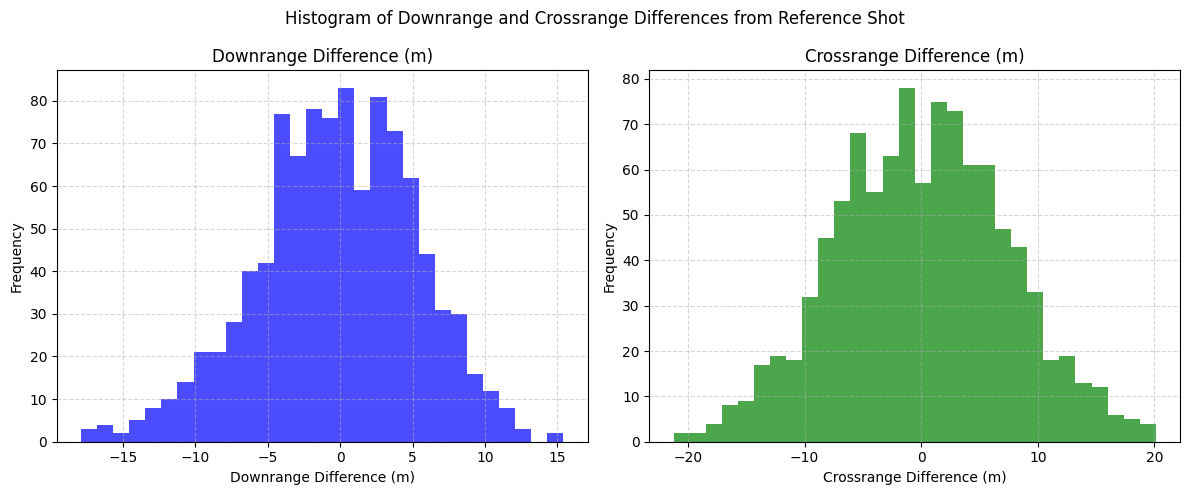

In [18]:
# plot histogram of downrange and crossrange differences
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
downrange_diff = np.array(results)[:, 0] - ref_point[0]
crossrange_diff = np.array(results)[:, 1] - ref_point[1]
ax[0].hist(downrange_diff, bins=30, color='blue', alpha=0.7)
ax[0].set_title('Downrange Difference (m)')
ax[0].set_xlabel('Downrange Difference (m)')
ax[0].set_ylabel('Frequency')
ax[0].grid(True, which='both', linestyle='--', alpha=0.5)
ax[1].hist(crossrange_diff, bins=30, color='green', alpha=0.7)
ax[1].set_title('Crossrange Difference (m)')
ax[1].set_xlabel('Crossrange Difference (m)')
ax[1].set_ylabel('Frequency')
ax[1].grid(True, which='both', linestyle='--', alpha=0.5)
plt.suptitle('Histogram of Downrange and Crossrange Differences from Reference Shot')
plt.tight_layout()
plt.show()


# Club-wise fluctuation sensitivity analysis

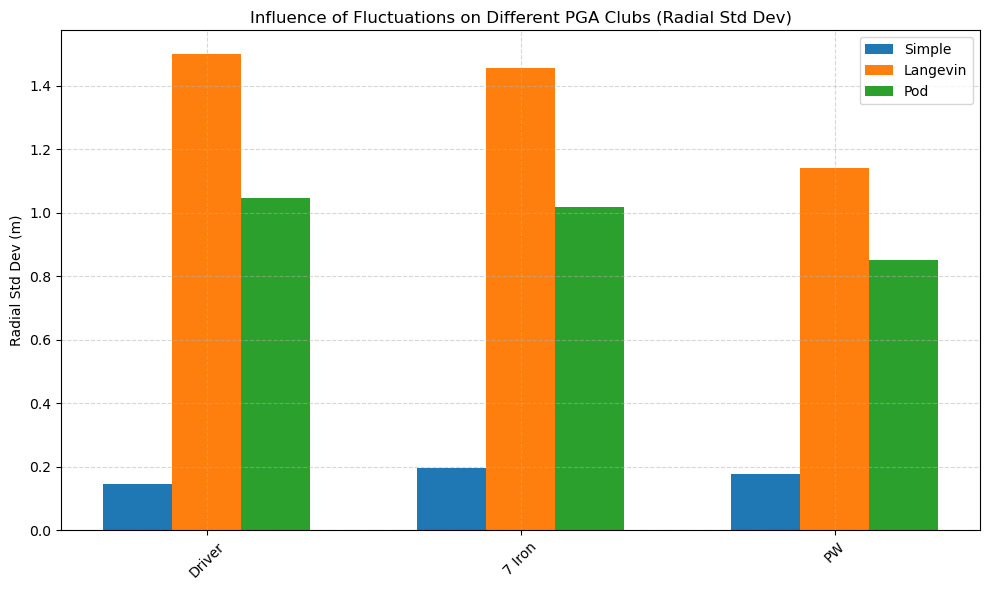

In [7]:
# Clubs to analyse
clubs = ['Driver', '7 Iron', 'PW']
methods = ['simple', 'langevin', 'pod']
N = 600

dt = 0.01
n_modes_pod = 9

# helper to simulate a single PGA shot with a given fluctuation
def simulate_pga_shot(club, method, wind, dt=0.01, n_modes=9, seed=None):
    if method.lower() == 'pod':
        fluc = Fluctuator(method='pod', n_modes=n_modes, seed=seed)
    else:
        fluc = Fluctuator(method=method, seed=seed)
    traj = PGA(club, fluc=fluc, wind=wind)
    traj.solve('euler', dt)
    return traj.p[-1][:2]

# run simulations
landing = {club: {m: None for m in methods} for club in clubs}
for club in clubs:
    for m in methods:
        results = Parallel(n_jobs=-1)(
            delayed(simulate_pga_shot)(club, m, wind, dt, n_modes_pod, i) for i in range(N)
        )
        landing[club][m] = np.array(results)

# compute reference (no fluctuations)
p_ref = {}
for club in clubs:
    traj = PGA(club, wind=wind)
    traj.solve('euler', dt)
    p_ref[club] = traj.p[-1][:2]

# compute radial std dev per club and method
stds = {m: [] for m in methods}
for m in methods:
    for club in clubs:
        diffs = landing[club][m] - p_ref[club]
        std_r = np.std(np.linalg.norm(diffs, axis=1))
        stds[m].append(std_r)

# plot grouped bar chart
x = np.arange(len(clubs))
width = 0.22
fig, ax = plt.subplots(figsize=(10,6))
for i,m in enumerate(methods):
    ax.bar(x + (i-1)*width, stds[m], width, label=m.title())
ax.set_xticks(x)
ax.set_xticklabels(clubs, rotation=45)
ax.set_ylabel('Radial Std Dev (m)')
ax.set_title('Influence of Fluctuations on Different PGA Clubs (Radial Std Dev)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# # scatter examples for Driver and 9 Iron using Langevin
# for club in ['Driver', '7 Iron', 'PW']:
#     pts = landing[club]['langevin'] - p_ref[club]
#     fig, ax = plt.subplots(figsize=(6,6))
#     ax.scatter(pts[:,0], pts[:,1], alpha=0.3)
#     ax.set_title(f'{club} - Langevin Fluctuation Scatter (N={N})')
#     ax.set_xlabel('Downrange Difference (m)')
#     ax.set_ylabel('Crossrange Difference (m)')
#     ax.axis('equal')
#     ax.grid(True)
#     plt.show()


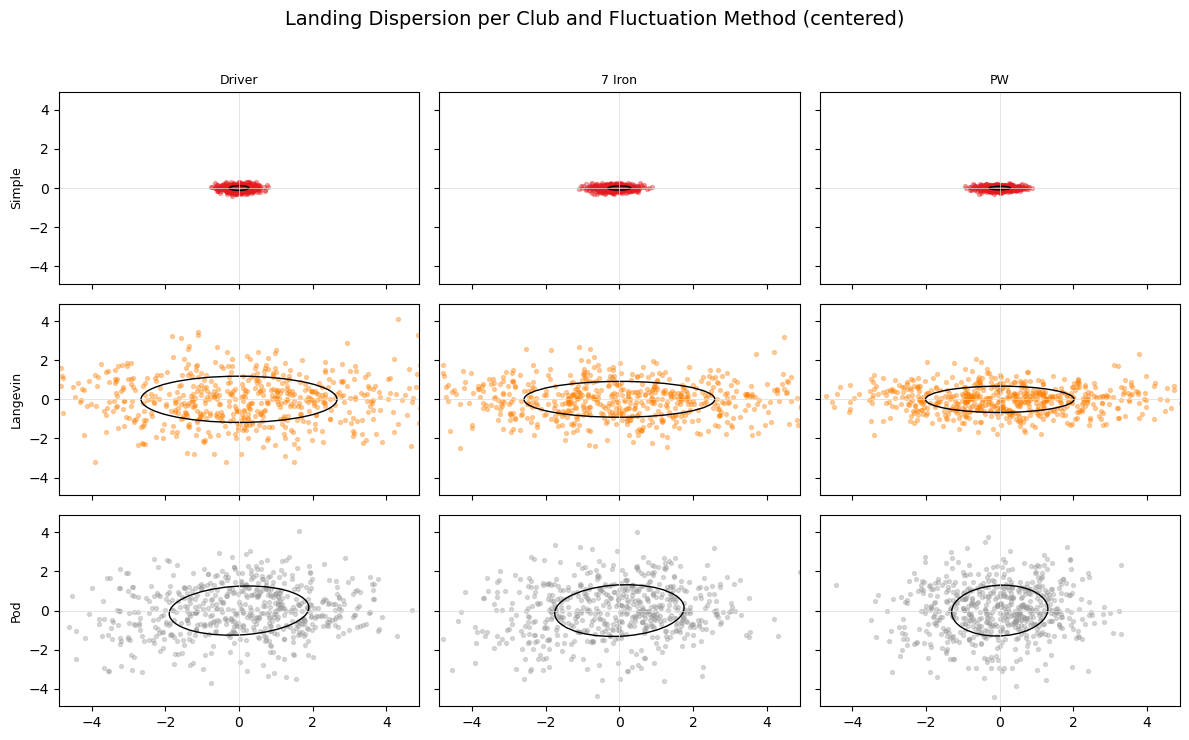

In [10]:
# Small-multiples scatter grid: one row per method, one column per club

rows = len(methods)
cols = len(clubs)
colors_row = plt.cm.Set1(np.linspace(0,1,rows))

fig, axs = plt.subplots(rows, cols, figsize=(max(12, cols*2.5), rows*2.5), sharex=True, sharey=True)

for i, m in enumerate(methods):
    for j, club in enumerate(clubs):
        pts = landing[club][m] - p_ref[club]
        ax = axs[i, j] if rows > 1 and cols > 1 else (axs[j] if rows==1 else axs[i])

        if pts.size == 0:
            ax.text(0.5, 0.5, 'no data', ha='center', va='center')
            continue

        ax.scatter(pts[:, 0], pts[:, 1], s=8, alpha=0.35, color=colors_row[i])
        ax.axvline(0, color='0.85', lw=0.5)
        ax.axhline(0, color='0.85', lw=0.5)

        # covariance ellipse (1-sigma) if data is sufficient
        if pts.shape[0] > 2:
            cov = np.cov(pts.T)
            if not np.any(np.isnan(cov)) and cov.shape == (2,2):
                vals, vecs = np.linalg.eigh(cov)
                order = vals.argsort()[::-1]
                vals = vals[order]
                vecs = vecs[:, order]
                angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
                width, height = 2 * np.sqrt(vals)  # diameter-like scaling for visibility
                ell = Ellipse((0, 0), width=width, height=height, angle=angle, edgecolor='k', facecolor='none', lw=1)
                ax.add_patch(ell)

        if i == 0:
            ax.set_title(club, fontsize=9)
        if j == 0:
            ax.set_ylabel(m.title(), fontsize=9)

        # keep axes symmetric and centered around zero for easy comparison
        lim = max(np.abs(pts).max() * 1.1, 2.0)
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)

# overall layout
plt.suptitle('Landing Dispersion per Club and Fluctuation Method (centered)', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
